# Derivative Of Gaussian step-edge example

A separable first derivative of Gaussian filter. This notebook creates a simple black-to-white step edge, runs the filter, and plots the result. The code is intentionally short so you can change the parameters and rerun the cells.


## How this filter works

The derivative-of-Gaussian filter smooths with a Gaussian while taking the first derivative. This gives a scale-controlled edge response. Larger `sigma` makes the derivative less sensitive to fine texture and noise. Year. The Gaussian derivative is a classical scale-space tool; Canny's 1986 edge detector made the first derivative of a Gaussian especially prominent in edge detection. Links. [Gaussian blur](https://en.wikipedia.org/wiki/Gaussian_blur) and [Canny edge detector](https://en.wikipedia.org/wiki/Canny_edge_detector). Related DOI. [10.1109/TPAMI.1986.4767851](https://doi.org/10.1109/TPAMI.1986.4767851).


## Setup

Import the small set of tools used in this notebook. The autoreload lines help Jupyter pick up local source edits without restarting the kernel every time.


In [7]:
# Imports and local reloads.
%load_ext autoreload
%autoreload 2

import time

import matplotlib.pyplot as plt
import torch

from agfb_filters import ExecutionPath, get_filter_definition, run_filter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Filter settings

Choose the filter settings here. The `definition` describes the filter, and the `path` chooses the matching execution path.


In [8]:
# Change these settings to try the filter.
sigma = 10.0
definition = get_filter_definition("derivative_of_gaussian", sigma=sigma)
path = ExecutionPath.SEPARABLE

## Test image

Create a test image. By default this is a synthetic step edge. The commented block lets you replace it with your own image file path.


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

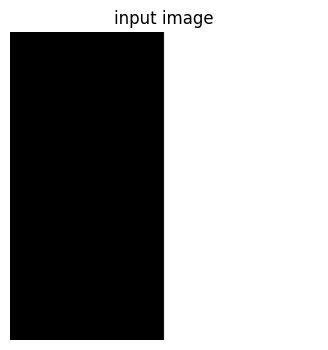

In [9]:
# Build the step-edge test image.
size = 1024
image = torch.zeros(1, size, size)
image[:, :, size // 2 :] = 1.0

# To use your own image instead, uncomment this block and set image_path.
# image_path = "path/to/image.png"
# image = torch.as_tensor(plt.imread(image_path), dtype=torch.float32)
# if image.ndim == 3:
#     image = image[..., :3].mean(dim=-1)
# image = image.unsqueeze(0)

plt.figure(figsize=(4, 4))
plt.imshow(image[0], cmap="gray", vmin=0, vmax=1)
plt.title("input image")
plt.axis("off")

## Filter weights

Visualize the fixed filter weights. `kernel_x` responds to left-to-right changes, and `kernel_y` responds to top-to-bottom changes.


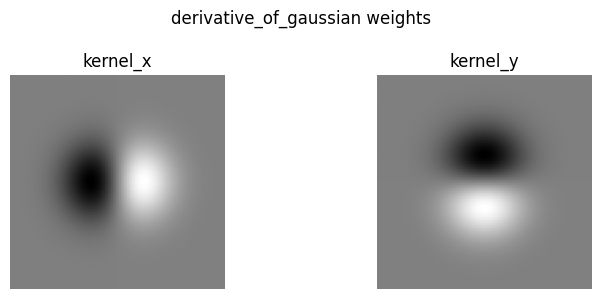

In [10]:
# Plot the filter weights.
kernel_x, kernel_y = definition.dense_kernels()
weight_limit = max(float(kernel_x.abs().max()), float(kernel_y.abs().max()))

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for ax, kernel, title in zip(
    axes,
    (kernel_x, kernel_y),
    ("kernel_x", "kernel_y"),
    strict=False,
):
    ax.imshow(kernel, cmap="gray", vmin=-weight_limit, vmax=weight_limit)
    ax.set_title(title)
    ax.axis("off")

fig.suptitle(f"{definition.name} weights")
fig.tight_layout()

## Run the filter

Run the filter. The timer measures only the filter call, not the image setup or plotting.


In [11]:
# Time the filter call.
start = time.perf_counter()
gradient_x, gradient_y = run_filter(
    definition,
    image,
    path=path,
    boundary=definition.default_boundary,
)
elapsed = time.perf_counter() - start

print(f"{elapsed:.4f} seconds")

0.2267 seconds


## Gradient results

Plot the two gradient outputs with the same grayscale range. The input changes left-to-right, so the strongest response should usually be in `gradient_x`.


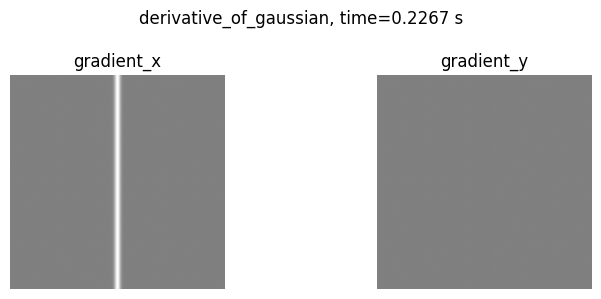

In [12]:
# Plot gradient_x and gradient_y.
limit = max(float(gradient_x.abs().max()), float(gradient_y.abs().max()))

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].imshow(gradient_x[0], cmap="gray", vmin=-limit, vmax=limit)
axes[0].set_title("gradient_x")

axes[1].imshow(gradient_y[0], cmap="gray", vmin=-limit, vmax=limit)
axes[1].set_title("gradient_y")

for ax in axes:
    ax.axis("off")

fig.suptitle(f"{definition.name}, time={elapsed:.4f} s")
fig.tight_layout()